# 01 - Exploratory Data Analysis - Card Fraud Detection

**Business question:** What does fraud actually look like in this portfolio, how big is the problem, what does a fraudulent transaction look like, who's affected, and when does it happen?

This notebook builds the fraud profile that later phases will build on:
- **Phase 2** will do systematic fraud-rate-by-column analysis and K-means clustering to segment risk more rigorously.
- **Phase 3** will build a predictive model to flag fraud in real time.

This EDA is intentionally kept at a *diagnostic, business-framed* level that enough to characterize the problem and form hypotheses, not an exhaustive statistical treatment.

**Data:** gold-layer table produced by the dbt pipeline (bronze → silver → gold), one row per transaction.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_parquet('../data/gold_card_transactions.parquet')
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head(3)

Rows: 590,540  |  Columns: 49


,is_fraud,transaction_id,transaction_time_offset,transaction_amount,product_code,c1,c2,c3,c4,c5,...,device_code_3,identity_record_status,identity_record_match,identity_flag_35,identity_flag_36,identity_flag_37,identity_flag_38,browser_version,device_type,device_info
0,0,3342667,8802753,60.54,C,2.00,2.00,0.00,0.00,0.00,...,266.00,Found,Found,False,False,True,False,chrome generic for android,mobile,SM-T700 Build/MMB29K
1,0,3307664,7963590,46.89,C,1.00,4.00,0.00,1.00,0.00,...,607.00,Found,Found,False,False,True,False,mobile safari generic,mobile,NaN
2,1,3537469,14531245,28.83,C,12.00,16.00,0.00,6.00,0.00,...,271.00,Found,Found,False,False,True,False,chrome 63.0 for android,mobile,CAM-L03 Build/HUAWEICAM-L03


## 1. The Scale of the Problem

Before looking at *how* fraud happens, it's worth establishing *how much it costs*. Fraud is a low-frequency event, but low frequency doesn't mean low stakes, a handful of large fraudulent transactions can matter more than the raw count suggests.

In [3]:
total_txns = len(df)
fraud_txns = df['is_fraud'].sum()
fraud_rate = fraud_txns / total_txns

total_value = df['transaction_amount'].sum()
fraud_value = df.loc[df['is_fraud'] == 1, 'transaction_amount'].sum()
fraud_value_share = fraud_value / total_value

summary = pd.DataFrame({
    'Metric': ['Total transactions', 'Fraudulent transactions', 'Fraud rate (by count)',
               'Total transaction value', 'Value lost to fraud', 'Fraud share of total value'],
    'Value': [f"{total_txns:,}", f"{fraud_txns:,}", f"{fraud_rate:.2%}",
              f"${total_value:,.0f}", f"${fraud_value:,.0f}", f"{fraud_value_share:.2%}"]
})
summary

,Metric,Value
0,Total transactions,"590,540"
1,Fraudulent transactions,"20,663"
2,Fraud rate (by count),3.50%
3,Total transaction value,"$79,738,949"
4,Value lost to fraud,"$3,083,845"
5,Fraud share of total value,3.87%


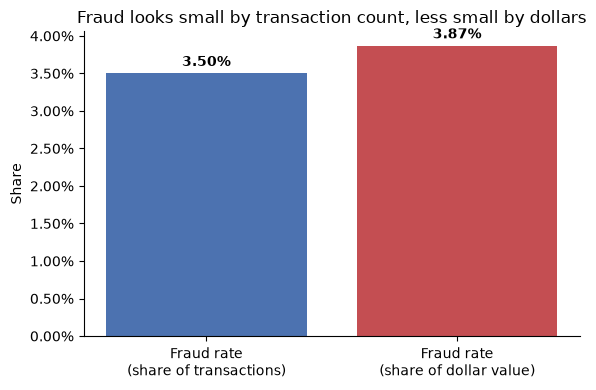

In [8]:
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Fraud rate\n(share of transactions)', 'Fraud rate\n(share of dollar value)'],
       [fraud_rate, fraud_value_share], color=['#4C72B0', '#C44E52'])
ax.set_ylabel('Share')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Fraud looks small by transaction count, less small by dollars')
for i, v in enumerate([fraud_rate, fraud_value_share]):
    ax.text(i, v + 0.001, f"{v:.2%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**What this means for the business:** about 3.5% of transactions are fraudulent, and fraud accounts for a very similar ~3.9% of total dollar volume, the two shares are close, so fraud isn't wildly concentrated in either unusually large or unusually small transactions overall. That still translates into a real dollar figure worth stating out loud when making the case for investment in detection (see the exact total above), it's the number a business case for this project would open with.

## 2. What Does a Fraudulent Transaction Look Like?

The obvious first lever: transaction amount. Do fraudsters go for small, easy-to-miss charges, or big-ticket amounts?

In [9]:
amount_stats = df.groupby('is_fraud')['transaction_amount'].describe(percentiles=[.25,.5,.75,.9,.99])
amount_stats.index = ['Legitimate', 'Fraudulent']
amount_stats

,count,mean,std,min,25%,50%,75%,90%,99%,max
Legitimate,"569,877.00",134.51,239.40,0.25,43.97,68.50,120.00,267.11,"1,104.00","31,937.39"
Fraudulent,"20,663.00",149.24,232.21,0.29,35.04,75.00,161.00,335.00,994.00,"5,191.00"


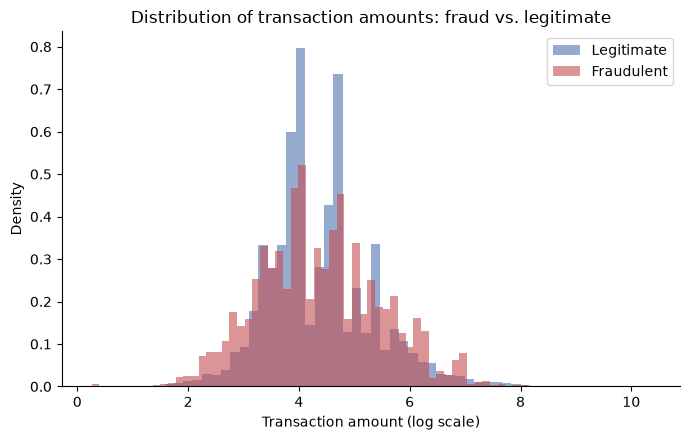

In [10]:
fig, ax = plt.subplots(figsize=(7,4.5))
data_legit = df.loc[df['is_fraud']==0, 'transaction_amount']
data_fraud = df.loc[df['is_fraud']==1, 'transaction_amount']

ax.hist(np.log1p(data_legit), bins=60, alpha=0.6, label='Legitimate', density=True, color="#4D73AF")
ax.hist(np.log1p(data_fraud), bins=60, alpha=0.6, label='Fraudulent', density=True, color='#C44E52')
ax.set_xlabel('Transaction amount (log scale)')
ax.set_ylabel('Density')
ax.set_title('Distribution of transaction amounts: fraud vs. legitimate')
ax.legend()
plt.tight_layout()
plt.show()

**What this means for the business:** fraudulent transactions have a slightly *higher* median (\$75 vs. \$68.50) and a somewhat fatter tail at the 90th percentile (\$335 vs. \$267) than legitimate ones but the two distributions clearly overlap heavily in the histogram above. Fraud is not confined to a distinct "high-dollar" bucket you could catch with a simple amount cutoff; most fraudulent transactions look like perfectly ordinary purchases. That's the core argument for a data-driven, multivariate detection approach rather than a manual dollar-threshold rule.

## 3. Who's Affected?

A first pass at where risk concentrates by card network/type, product category, and device. This is a high-level scan; the exhaustive column-by-column fraud-rate analysis is deferred to Phase 2.

In [6]:
def fraud_rate_by(col, min_count=50):
    g = df.assign(**{col: df[col].fillna('Unknown')}).groupby(col)['is_fraud'].agg(['count','mean'])
    g = g[g['count'] >= min_count].sort_values('mean', ascending=False)
    g.columns = ['Transactions', 'Fraud rate']
    return g

by_product = fraud_rate_by('product_code')
by_network = fraud_rate_by('card_network')
by_cardtype = fraud_rate_by('card_type')
by_device = fraud_rate_by('device_type')

by_product

,Transactions,Fraud rate
product_code,,
C,68519,0.12
S,11628,0.06
H,33024,0.05
R,37699,0.04
W,439670,0.02


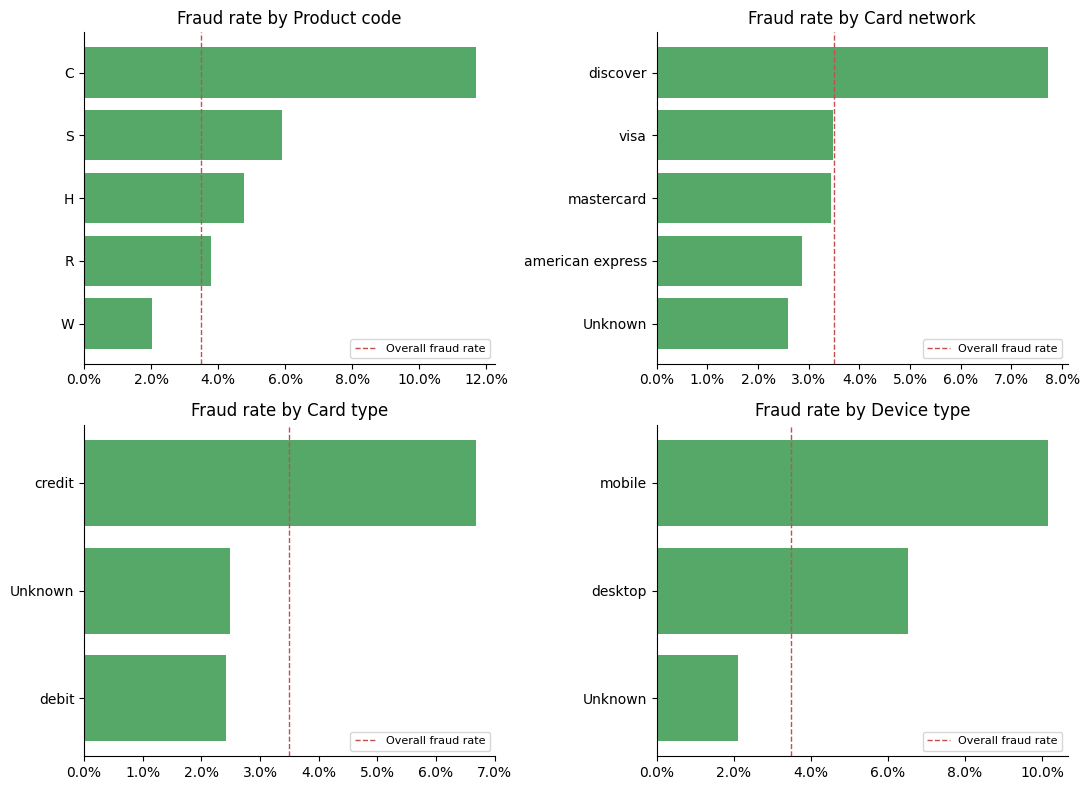

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11,8))
plot_specs = [
    (by_product, 'Product code', axes[0,0]),
    (by_network, 'Card network', axes[0,1]),
    (by_cardtype, 'Card type', axes[1,0]),
    (by_device, 'Device type', axes[1,1]),
]
overall_rate = df['is_fraud'].mean()

for g, title, ax in plot_specs:
    g = g.sort_values('Fraud rate', ascending=True)
    ax.barh(g.index.astype(str), g['Fraud rate'], color='#55A868')
    ax.axvline(overall_rate, color='#C44E52', linestyle='--', linewidth=1, label='Overall fraud rate')
    ax.set_title(f'Fraud rate by {title}')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**What this means for the business:** the red dashed line marks the overall fraud rate (~3.5%), any bar sitting well above it is a segment worth extra scrutiny (e.g. step-up authentication, lower approval limits), and any bar well below it is a segment where friction could safely be reduced. Two concrete patterns stand out: **credit cards run roughly 3x the fraud rate of debit cards**, and **mobile transactions run nearly double the rate of desktop**. The device-type "Unknown" segment is worth a second look for a different reason than expected, it actually shows the *lowest* fraud rate of the three groups, not the highest. That's counter to the usual assumption that "missing data = higher risk," and is a good example of why we test assumptions on the data rather than carrying folk wisdom into Phase 2 unexamined.

## 4. When Does It Happen?

`transaction_time_offset` is a running count of seconds from the start of the observation window (about 6 months of data). We can derive a day index and hour-of-day to check for timing patterns.

In [8]:
df['day_number'] = (df['transaction_time_offset'] // 86400).astype(int)
df['hour_of_day'] = ((df['transaction_time_offset'] // 3600) % 24).astype(int)

fraud_by_hour = df.groupby('hour_of_day')['is_fraud'].agg(['count','mean'])
fraud_by_hour.columns = ['Transactions', 'Fraud rate']
fraud_by_hour

,Transactions,Fraud rate
hour_of_day,,
0,37795,0.03
1,32797,0.03
2,26732,0.04
3,20802,0.04
4,14839,0.05
5,9701,0.07
6,6007,0.08
7,3704,0.11
8,2591,0.09


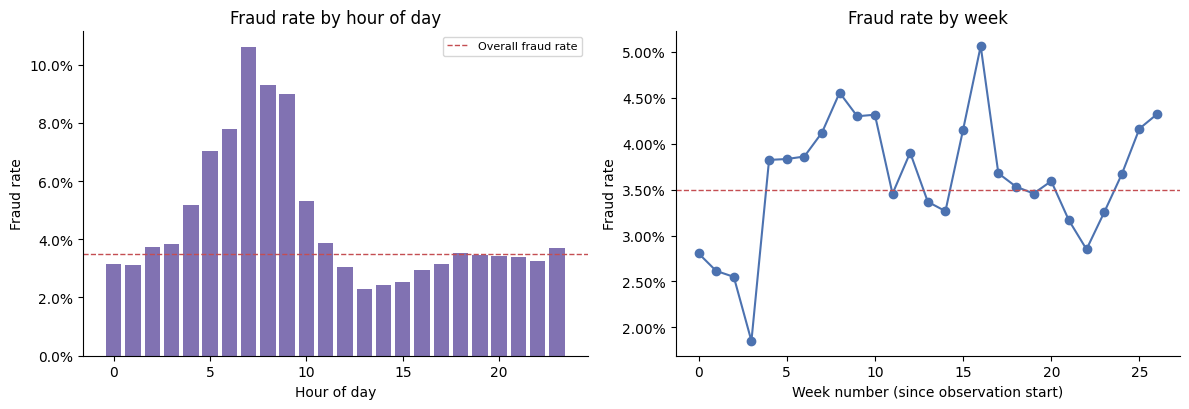

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.2))

axes[0].bar(fraud_by_hour.index, fraud_by_hour['Fraud rate'], color='#8172B2')
axes[0].axhline(overall_rate, color='#C44E52', linestyle='--', linewidth=1, label='Overall fraud rate')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Fraud rate')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_title('Fraud rate by hour of day')
axes[0].legend(fontsize=8)

weekly = df.groupby(df['day_number'] // 7)['is_fraud'].mean()
axes[1].plot(weekly.index, weekly.values, marker='o', color='#4C72B0')
axes[1].axhline(overall_rate, color='#C44E52', linestyle='--', linewidth=1)
axes[1].set_xlabel('Week number (since observation start)')
axes[1].set_ylabel('Fraud rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_title('Fraud rate by week')

plt.tight_layout()
plt.show()

**What this means for the business:** fraud rate roughly doubles-to-triples during a specific stretch of hours relative to the daily average, and drops off outside that window, a real, usable pattern for staffing fraud-review teams or tuning stricter authentication rules to specific hours rather than applying them uniformly around the clock. One caveat: the underlying time field is an anonymized offset from an unspecified start point, so we can describe the *shape* of the daily pattern (a clear elevated window vs. a clear low window) but shouldn't claim it maps to a specific real-world clock time (e.g. "3am") without confirming the reference point with whoever supplied the data. Week-over-week, the fraud rate is fairly stable (roughly 1.9%–5.1%, no runaway trend) — this reads as a persistent baseline risk to manage continuously, not a one-off spike to patch.

## 5. Summary & What This Sets Up

**Fraud profile at a glance:**
- **Scale:** ~3.5% of transactions are fraudulent, representing ~3.9% of total dollar volume,a real and quantifiable exposure worth stating as a dollar figure in any business case (Section 1).
- **Transaction size:** fraudulent transactions run only slightly higher than legitimate ones on average and overlap heavily in distribution which means fraud hides in ordinary-looking amounts, so a simple dollar-threshold rule is a weak control on its own (Section 2).
- **Where it concentrates:** credit cards, mobile transactions, certain product codes, and the Discover network all carry above-average fraud rates. Notably, transactions with *missing* device information actually show the *lowest* fraud rate of any device segment.
- **When it happens:** fraud rate varies clearly by time of day, roughly doubling-to-tripling during a specific window versus the daily low, useful for shaping when stricter review or authentication kicks in while staying fairly stable week over week, suggesting a persistent baseline risk rather than a seasonal spike (Section 4).

**Bridge to Phase 2:** the segment-level differences surfaced here (by product, card type, device) are exactly the signal we'll test more rigorously with fraud-rate-by-column analysis and K-means clustering, this notebook tells us *where to look*, Phase 2 will tell us *how distinct and reliable those groupings really are*.

**Bridge to Phase 3:** the fact that fraud doesn't separate cleanly on transaction amount alone is the core argument for a multivariate predictive model rather than simple business rules.
